<a href="https://colab.research.google.com/github/Donthula-Harika/Data_Analysis_Assignments/blob/main/Assignment%202%20-%20Amazon%20Products%20Data%20Analysis/Assignment_2_Amazon_Products_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 2 - Amazon Products Data Analysis


##Task 1 — Load & Inspect the Dataset

1. Load the dataset into your notebook.
2. Display first and last 5 rows.
3. Print .shape and .info().
4. Show list of unique product categories.
5. Identify columns that require cleaning or type conversion.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Data Sets/amazon_products_dataset.csv')

In [4]:
df.head()


,title,brand,category,actual_price,discount_price,rating,rating_count
0,Smart Fitness Watch,Dell,Laptop,69890.0,65271.0,2.6,2128.0
1,Laptop with SSD Storage,LG,Smartwatch,66771.0,63977.0,2.5,9118.0
2,High Resolution Monitor,Mi,Headphones,43598.0,39679.0,1.9,2517.0
3,4K Action Camera,HP,Camera,63408.0,58877.0,3.7,17533.0
4,Smart Fitness Watch,Samsung,Monitor,49224.0,45017.0,4.9,14228.0


In [5]:
df.tail()

,title,brand,category,actual_price,discount_price,rating,rating_count
1995,Smartphone with AMOLED Display,Dell,Monitor,24140.0,20202.0,3.0,16058.0
1996,Smart Fitness Watch,LG,Headphones,65449.0,64559.0,1.1,6655.0
1997,4K Action Camera,Dell,Smartphone,21358.0,18654.0,3.7,5308.0
1998,Noise Cancelling Earbuds,OnePlus,Smartwatch,35229.0,31061.0,2.2,19105.0
1999,Smartphone with AMOLED Display,Boat,Headphones,31662.0,31047.0,3.2,1064.0


In [6]:
df.shape

(2000, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           2000 non-null   object 
 1   brand           2000 non-null   object 
 2   category        1998 non-null   object 
 3   actual_price    1998 non-null   float64
 4   discount_price  1999 non-null   float64
 5   rating          1996 non-null   float64
 6   rating_count    1996 non-null   float64
dtypes: float64(4), object(3)
memory usage: 109.5+ KB


In [18]:
#Show list of unique product categories.
print(df['category'].unique())
print(df['category'].nunique())
print("NaN values are NOT counted")

['Laptop' 'Smartwatch' 'Headphones' 'Camera' 'Monitor' 'Speaker' 'Tablet'
 'Smartphone' nan]
8
NaN values are NOT counted


In [19]:
#Identify columns that require cleaning or type conversion.
df.isnull().sum()

,0
title,0
brand,0
category,2
actual_price,2
discount_price,1
rating,4
rating_count,4


In [20]:
df.dtypes

,0
title,object
brand,object
category,object
actual_price,float64
discount_price,float64
rating,float64
rating_count,float64


- No cols require type conversion

##Task 2 — Clean the Dataset

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           2000 non-null   object 
 1   brand           2000 non-null   object 
 2   category        1998 non-null   object 
 3   actual_price    1998 non-null   float64
 4   discount_price  1999 non-null   float64
 5   rating          1996 non-null   float64
 6   rating_count    1996 non-null   float64
dtypes: float64(4), object(3)
memory usage: 109.5+ KB


In [22]:
#Identify missing values using .isnull().sum().
df.isnull().sum()

,0
title,0
brand,0
category,2
actual_price,2
discount_price,1
rating,4
rating_count,4


In [25]:
#Fill missing numeric values (discount_price, rating, etc.) using mean or median.

# num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# for col in num_cols:
#     df[col] = df[col].fillna(df[col].median())   # median is robust

df["discount_price"].fillna(df["discount_price"].median(), inplace=True)
df["rating"].fillna(df["rating"].mean(), inplace=True)
df["rating_count"].fillna(df["rating_count"].median(), inplace=True)
df['actual_price'].fillna(df['actual_price'].mean(),inplace=True)




/tmp/ipython-input-1171375888.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["discount_price"].fillna(df["discount_price"].median(), inplace=True)
/tmp/ipython-input-1171375888.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

Mean vs Median

Mean → when data is balanced

Median → when data has outliers (recommended for prices)

Since price columns were highly right-skewed with extreme high-value products, median was used to avoid distortion caused by outliers. Ratings were bounded between 1 and 5 and showed no extreme values, so mean imputation was applied. Categorical missing values were filled with “Unknown” to preserve records without introducing bias.

In [26]:
#Fill missing categorical values (brand, category) with "Unknown".
df["brand"].fillna("Unknown", inplace=True)
df["category"].fillna("Unknown", inplace=True)

/tmp/ipython-input-301512587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["brand"].fillna("Unknown", inplace=True)
/tmp/ipython-input-301512587.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [27]:
df.isnull().sum()

,0
title,0
brand,0
category,0
actual_price,0
discount_price,0
rating,0
rating_count,0


In [29]:
df.shape

(2000, 7)

In [30]:
#Remove all duplicate rows.
df.drop_duplicates(inplace=True)

In [31]:
df.shape

(2000, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           2000 non-null   object 
 1   brand           2000 non-null   object 
 2   category        2000 non-null   object 
 3   actual_price    2000 non-null   float64
 4   discount_price  2000 non-null   float64
 5   rating          2000 non-null   float64
 6   rating_count    2000 non-null   float64
dtypes: float64(4), object(3)
memory usage: 109.5+ KB


In [32]:
#Convert numeric columns to their correct data types.
numeric_cols = ['actual_price', 'discount_price', 'rating', 'rating_count']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           2000 non-null   object 
 1   brand           2000 non-null   object 
 2   category        2000 non-null   object 
 3   actual_price    2000 non-null   float64
 4   discount_price  2000 non-null   float64
 5   rating          2000 non-null   float64
 6   rating_count    2000 non-null   float64
dtypes: float64(4), object(3)
memory usage: 109.5+ KB


In [34]:
# 4. Reset index after cleaning
df = df.reset_index(drop=True)

##Task 3 — Data Analysis


In [35]:
#Identify the top 5 most expensive products (actual_price).
df['actual_price'].sort_values(ascending=False).head(5)

,actual_price
1383,79993.0
1974,79869.0
1403,79857.0
1351,79853.0
42,79826.0


In [36]:
top5_expensive = df.nlargest(5, 'actual_price')
top5_expensive


,title,brand,category,actual_price,discount_price,rating,rating_count
1383,Android Tablet,JBL,Laptop,79993.0,78094.0,3.0,7666.0
1974,Gaming Laptop,LG,Monitor,79869.0,77173.0,2.6,5232.0
1403,4K Action Camera,Sony,Headphones,79857.0,77469.0,2.7,1379.0
1351,Android Tablet,Sony,Monitor,79853.0,78831.0,4.8,7596.0
42,Gaming Laptop,Apple,Smartwatch,79826.0,76919.0,3.8,10252.0


In [38]:
top_5_expensive = df.sort_values(by="actual_price", ascending=False).head(5)
top_5_expensive


,title,brand,category,actual_price,discount_price,rating,rating_count
1383,Android Tablet,JBL,Laptop,79993.0,78094.0,3.0,7666.0
1974,Gaming Laptop,LG,Monitor,79869.0,77173.0,2.6,5232.0
1403,4K Action Camera,Sony,Headphones,79857.0,77469.0,2.7,1379.0
1351,Android Tablet,Sony,Monitor,79853.0,78831.0,4.8,7596.0
42,Gaming Laptop,Apple,Smartwatch,79826.0,76919.0,3.8,10252.0


In [39]:
#Find the brand with the highest number of products.
df['brand'].value_counts().idxmax()

'Boat'

In [40]:
#Compute the average discount percentage for each brand.
df['discount_percent'] = ((df['actual_price'] - df['discount_price']) / df['actual_price']) * 100
df['discount_percent'].groupby(df['brand']).mean()

,discount_percent
brand,
Apple,12.721996
Boat,12.546502
Dell,11.165004
HP,11.501202
JBL,11.370137
LG,11.968799
Mi,10.162308
OnePlus,11.380987
Samsung,9.326064


In [41]:
#Identify products with rating ≥ 4.5 and rating_count ≥ 2000.
df[(df['rating'] >= 4.5) & (df['rating_count'] >= 2000)]

,title,brand,category,actual_price,discount_price,rating,rating_count,discount_percent
4,Smart Fitness Watch,Samsung,Monitor,49224.0,45017.0,4.9,14228.0,8.546644
32,4K Action Camera,OnePlus,Smartphone,7793.0,5953.0,4.6,5066.0,23.610933
51,Wireless Bluetooth Headphones,Dell,Headphones,61569.0,59372.0,4.5,13402.0,3.568354
52,Laptop with SSD Storage,Boat,Smartwatch,76286.0,75621.0,5.0,7433.0,0.871720
59,Gaming Laptop,Samsung,Tablet,45250.0,44710.0,4.7,4643.0,1.193370
...,...,...,...,...,...,...,...,...
1949,Portable Bluetooth Speaker,OnePlus,Tablet,59325.0,55777.0,4.5,19070.0,5.980615
1970,Android Tablet,Boat,Camera,20841.0,17765.0,4.5,10252.0,14.759369
1975,Wireless Bluetooth Headphones,Samsung,Smartwatch,31973.0,27058.0,4.5,4288.0,15.372345
1982,Wireless Bluetooth Headphones,HP,Camera,15343.0,10814.0,4.5,7851.0,29.518347


In [42]:
#Compute category-wise average price.
df['actual_price'].groupby(df['category']).mean()

,actual_price
category,
Camera,40352.246094
Headphones,39576.147679
Laptop,40822.874477
Monitor,39949.431596
Smartphone,37909.529412
Smartwatch,38316.913934
Speaker,39683.449141
Tablet,39943.815217
Unknown,33610.500000


## Task 4 — Programming Task: Feature Engineering + Logical Filters



###Task 4A — Create New Columns

In [43]:
#price_category based on:
#actual_price < 500 → "Budget"
# 500 ≤ price < 2000 → "Midrange"
# price ≥ 2000 → "Premium"

def categorize_price(x):
    if x < 500:
        return "Budget"
    elif x < 2000:
        return "Midrange"
    else:
        return "Premium"

df['price_category'] = df['actual_price'].apply(categorize_price)

#popularity_score = rating * log(rating_count + 1)
df['popularity_score'] = df['rating'] * np.log(df['rating_count'] + 1)


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             2000 non-null   object 
 1   brand             2000 non-null   object 
 2   category          2000 non-null   object 
 3   actual_price      2000 non-null   float64
 4   discount_price    2000 non-null   float64
 5   rating            2000 non-null   float64
 6   rating_count      2000 non-null   float64
 7   discount_percent  2000 non-null   float64
 8   price_category    2000 non-null   object 
 9   popularity_score  2000 non-null   float64
dtypes: float64(6), object(4)
memory usage: 156.4+ KB


###Task 4B — Filtering Using New Columns

In [45]:
#Show top 10 highest popularity_score products.

df['popularity_score'].sort_values(ascending=False).head(10)

,popularity_score
1418,49.130602
297,48.928304
502,48.625690
1400,48.388891
878,48.248857
1489,48.240292
848,48.157775
854,48.040676
1625,47.848110
637,47.803700


In [46]:
df.head()

,title,brand,category,actual_price,discount_price,rating,rating_count,discount_percent,price_category,popularity_score
0,Smart Fitness Watch,Dell,Laptop,69890.0,65271.0,2.6,2128.0,6.608957,Premium,19.924860
1,Laptop with SSD Storage,LG,Smartwatch,66771.0,63977.0,2.5,9118.0,4.184451,Premium,22.795289
2,High Resolution Monitor,Mi,Headphones,43598.0,39679.0,1.9,2517.0,8.988944,Premium,14.879318
3,4K Action Camera,HP,Camera,63408.0,58877.0,3.7,17533.0,7.145786,Premium,36.156019
4,Smart Fitness Watch,Samsung,Monitor,49224.0,45017.0,4.9,14228.0,8.546644,Premium,46.858883


In [47]:
#Show all Premium category items with discount_percent > 40%.
df[(df['price_category'] =='Premium') & (df['discount_percent']>40)]

,title,brand,category,actual_price,discount_price,rating,rating_count,discount_percent,price_category,popularity_score
6,Smartphone with AMOLED Display,OnePlus,Laptop,10026.0,5451.0,3.4,18262.0,45.631358,Premium,33.362950
20,4K Action Camera,OnePlus,Headphones,4378.0,103.0,2.7,6412.0,97.647328,Premium,23.668423
53,Noise Cancelling Earbuds,JBL,Camera,2335.0,1338.0,3.4,11284.0,42.698073,Premium,31.726181
74,High Resolution Monitor,Boat,Monitor,5137.0,440.0,1.1,3605.0,91.434690,Premium,9.009390
104,High Resolution Monitor,Sony,Tablet,4933.0,1146.0,2.3,19888.0,76.768701,Premium,22.765221
...,...,...,...,...,...,...,...,...,...,...
1793,High Resolution Monitor,Mi,Headphones,3620.0,1463.0,4.0,17890.0,59.585635,Premium,39.168212
1834,Wireless Bluetooth Headphones,Boat,Headphones,5377.0,790.0,1.4,619.0,85.307792,Premium,9.001607
1841,Noise Cancelling Earbuds,OnePlus,Smartwatch,5877.0,1234.0,3.0,4039.0,79.002893,Premium,24.912000
1875,Wireless Bluetooth Headphones,Dell,Laptop,11037.0,6048.0,1.1,15668.0,45.202501,Premium,10.625383


In [48]:
#Show all products whose title contains "Bluetooth" (string filter).
df[
    df['title'].str.contains("Bluetooth", case=False, na=False)
]

,title,brand,category,actual_price,discount_price,rating,rating_count,discount_percent,price_category,popularity_score
14,Portable Bluetooth Speaker,OnePlus,Camera,25516.0,24050.0,1.7,16989.0,5.745415,Premium,16.558646
18,Portable Bluetooth Speaker,Sony,Monitor,73590.0,69414.0,3.8,9759.0,5.674684,Premium,34.906981
21,Wireless Bluetooth Headphones,Samsung,Speaker,78689.0,76240.0,2.9,10196.0,3.112252,Premium,26.766562
23,Portable Bluetooth Speaker,HP,Smartwatch,4342.0,4235.0,1.4,4820.0,2.464302,Premium,11.873031
25,Wireless Bluetooth Headphones,Boat,Monitor,14689.0,13286.0,3.7,1849.0,9.551365,Premium,27.834881
...,...,...,...,...,...,...,...,...,...,...
1975,Wireless Bluetooth Headphones,Samsung,Smartwatch,31973.0,27058.0,4.5,4288.0,15.372345,Premium,37.637140
1979,Wireless Bluetooth Headphones,Sony,Monitor,65124.0,61923.0,3.3,16581.0,4.915239,Premium,32.063041
1982,Wireless Bluetooth Headphones,HP,Camera,15343.0,10814.0,4.5,7851.0,29.518347,Premium,40.358356
1985,Wireless Bluetooth Headphones,Mi,Smartwatch,50527.0,45694.0,2.8,3692.0,9.565183,Premium,22.999744


In [50]:
# Show products where:
# rating >= 4.0
# discount_percent between 20% to 50%
# popularity_score in the top 30% percentile
# (Use .between() and .quantile())


discount_mask = df['discount_percent'].between(20, 50)
popularity_cutoff = df['popularity_score'].quantile(0.7)  # top 30%

filtered_products = df[
    (df['rating'] >= 4.0) &
    discount_mask &
    (df['popularity_score'] >= popularity_cutoff)
]
print(filtered_products)

                               title    brand    category  actual_price  \
32                  4K Action Camera  OnePlus  Smartphone        7793.0   
94               Smart Fitness Watch       HP     Monitor       16289.0   
107          High Resolution Monitor      JBL  Smartphone        7308.0   
140                    Gaming Laptop     Sony      Tablet       11869.0   
162                   Android Tablet    Apple     Speaker       11918.0   
165    Wireless Bluetooth Headphones    Apple  Smartwatch        7654.0   
188       Portable Bluetooth Speaker       LG  Smartphone       10227.0   
215    Wireless Bluetooth Headphones    Apple      Camera       16855.0   
274   Smartphone with AMOLED Display     Sony     Speaker        6770.0   
404       Portable Bluetooth Speaker  Samsung      Laptop       14978.0   
469                   Android Tablet     Boat      Laptop        8287.0   
480          Laptop with SSD Storage       HP     Monitor         366.0   
482                 4K Ac

###Task 4C — Grouping with New Columns

In [51]:
#Find the average discount_percent for each brand.
df['discount_percent'].groupby(df['brand']).mean()

,discount_percent
brand,
Apple,12.721996
Boat,12.546502
Dell,11.165004
HP,11.501202
JBL,11.370137
LG,11.968799
Mi,10.162308
OnePlus,11.380987
Samsung,9.326064


In [52]:
#Find the average popularity_score for each price_category.
df['popularity_score'].groupby(df['price_category']).mean()

,popularity_score
price_category,
Budget,38.147220
Midrange,23.660324
Premium,26.366855


In [53]:
#Identify which category offers the highest average discount.
df['discount_percent'].groupby(df['category']).mean().idxmax()

'Headphones'

In [54]:
#Calculate total revenue potential per brand using:
#revenue_potential = actual_price * rating_countv
df['revenue_potential'] = df['actual_price'] * df['rating_count']
df['revenue_potential'].groupby(df['brand']).sum()

,revenue_potential
brand,
Apple,6.705514e+10
Boat,7.744207e+10
Dell,7.549826e+10
HP,8.297444e+10
JBL,7.723438e+10
LG,8.157168e+10
Mi,7.698029e+10
OnePlus,8.247380e+10
Samsung,8.117230e+10


##Task 5 — Data Visualization


<Axes: xlabel='actual_price', ylabel='Count'>

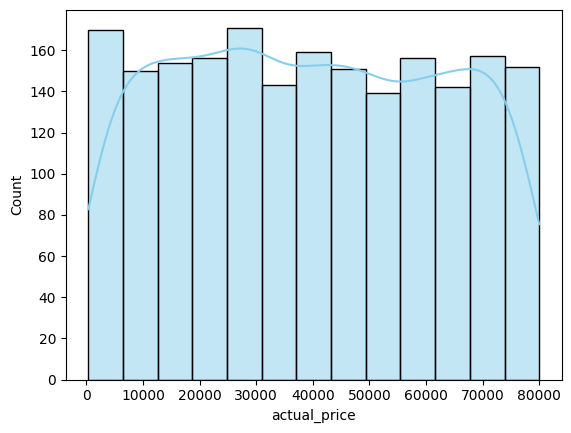

In [55]:
#Price distribution → Histogram + KDE
# plt.figure(figsize=(10, 6))
sns.histplot(df['actual_price'], kde=True,  color='skyblue')

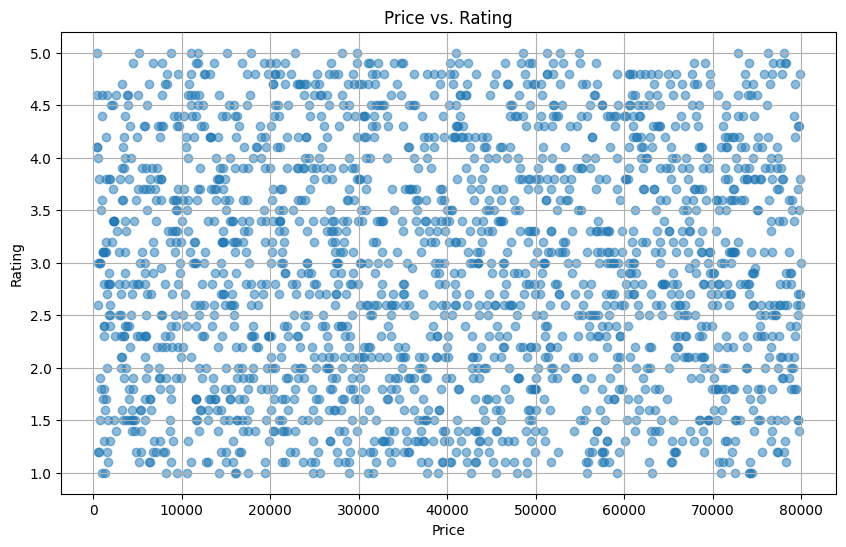

In [56]:
#Relationship between price and rating → Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['actual_price'], df['rating'], alpha=0.5)
plt.title('Price vs. Rating')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Average Rating')

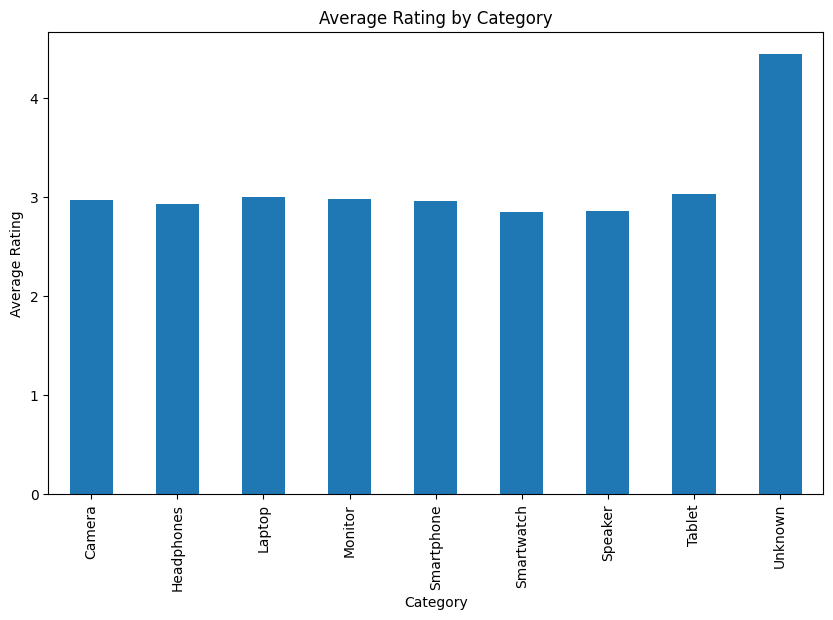

In [57]:
#Category-wise average rating → Bar Plot
plt.figure(figsize=(10, 6))
df['rating'].groupby(df['category']).mean().plot(kind='bar')
plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')

Text(0.5, 1.0, 'Product Count by Brand')

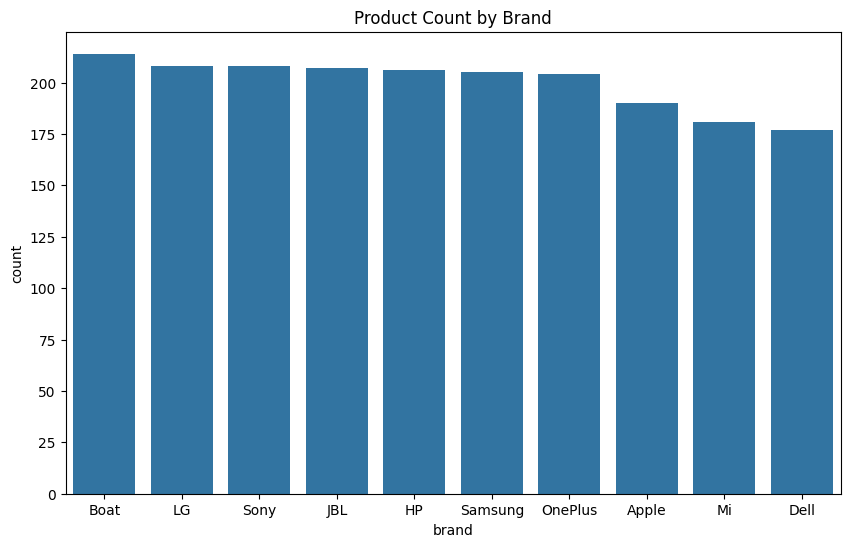

In [58]:
#Brand product count → Count Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index)
plt.title('Product Count by Brand')

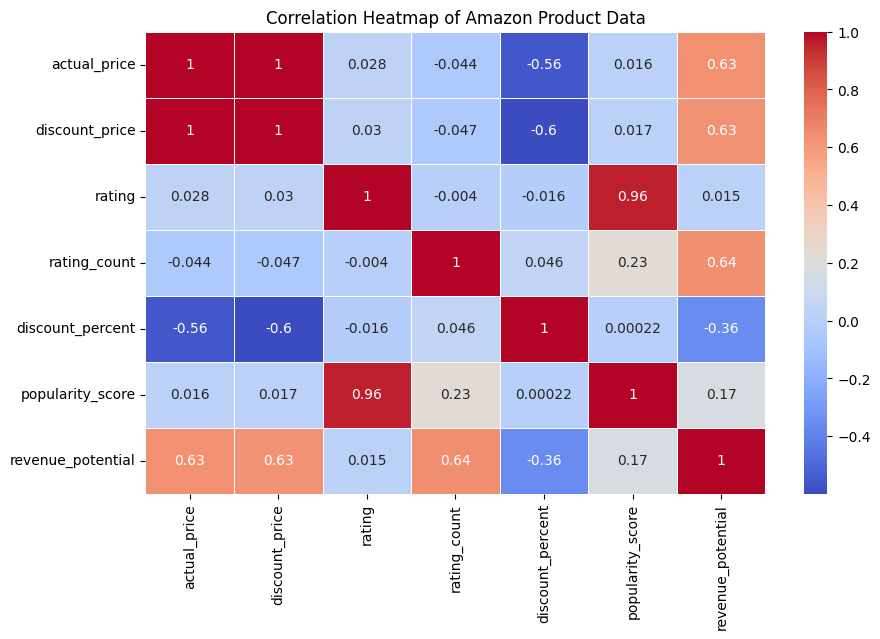

In [61]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Amazon Product Data")
plt.show()
